In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
from SpaLP.utils import transfer_labels_by_cosine
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### Pre-training data using one slice

In [4]:
adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.078.h5ad')
adata.var_names_make_unique()
adata.obs['type']='Pre-training data'

In [5]:
sc.pp.scale(adata)
adata.obsm['feat']=adata.X

In [6]:
k=16
graph = prepare_inputs(adata, k, device)

In [7]:
in_channels = graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    loss = criterion(reconstructed, graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 47.94it/s, Epoch=199, Loss=0.9014]


In [9]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [10]:
adata.obsm['SpaLP']=embedding

In [11]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/78_pretrian_model.pth")

In [12]:
adata.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/Pre-training.h5ad',compression='gzip')

### Inference data using two slices

In [13]:
adata1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.076.h5ad')
adata1.var_names_make_unique()
adata1.obs['type']='Inference data1'

adata2=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.077.h5ad')
adata2.var_names_make_unique()
adata2.obs['type']='Inference data2'

In [14]:
sc.pp.scale(adata1)
adata1.obsm['feat']=adata1.X

sc.pp.scale(adata2)
adata2.obsm['feat']=adata2.X

In [15]:
graph1 = prepare_inputs(adata1, k=16, device=device)
graph2 = prepare_inputs(adata2, k=16, device=device)

### zero-shot inference embedding

In [16]:
in_channels = graph1.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph1.features, graph1.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata1.obsm['SpaLP']=embedding

In [17]:
in_channels = graph2.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph2.features, graph2.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata2.obsm['SpaLP']=embedding

### Label transfer on inference data1 using cosine similarity

In [18]:
Pre_train_adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/Pre-training.h5ad')

In [46]:
adata1=transfer_labels_by_cosine(pre_adata=Pre_train_adata, new_adata=adata1, label_key="major_brain_region", embedding_key="SpaLP")

In [47]:
adata1

AnnData object with n_obs × n_vars = 42854 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'Transfer_label', 'Confidence', 'Uncertainty'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title',

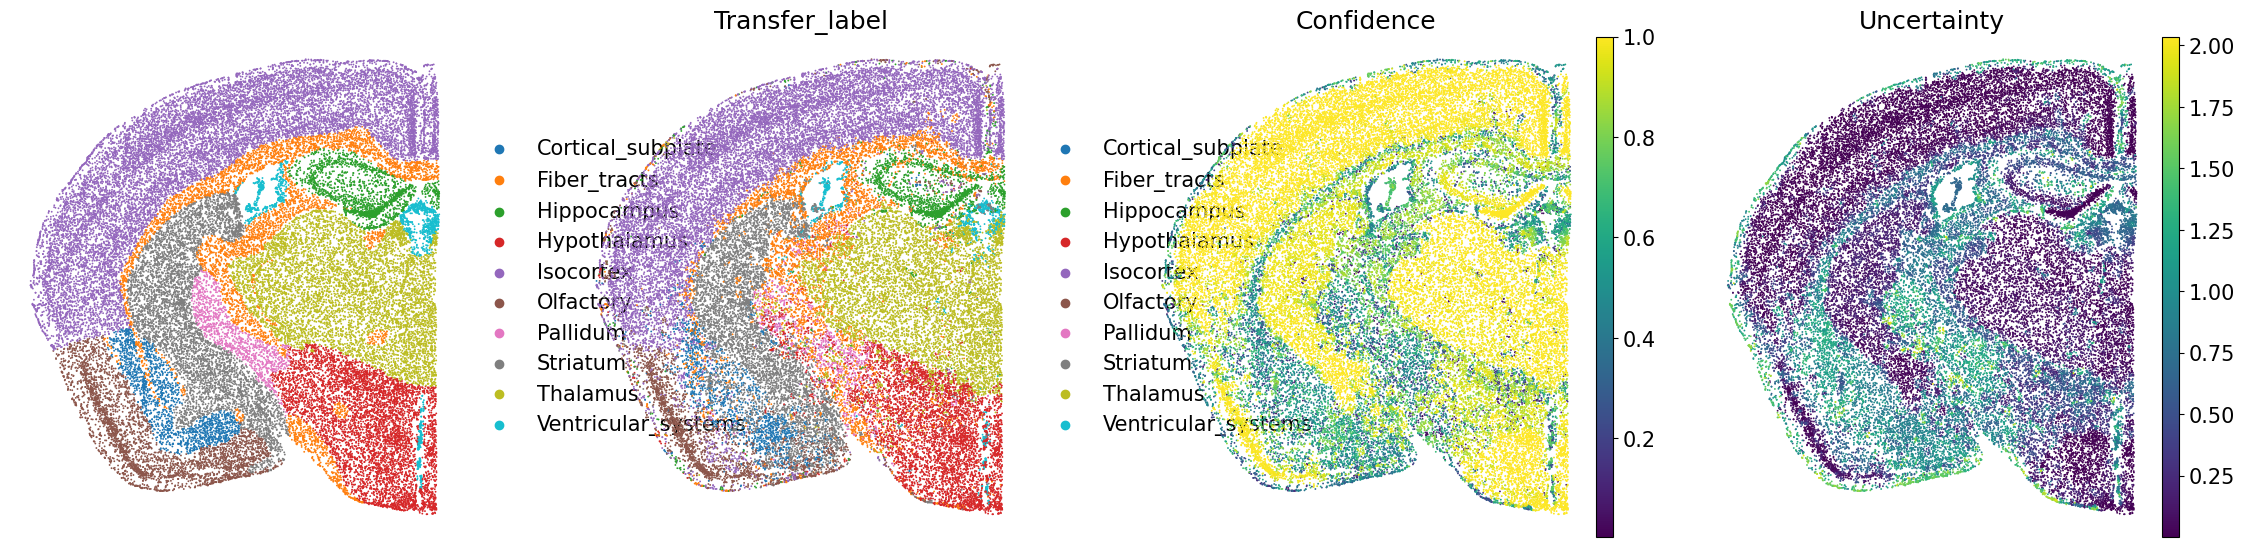

In [48]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata1, basis="spatial",s=7,color=['major_brain_region','Transfer_label','Confidence','Uncertainty'],title='',frameon=False)

### Clustering metrics

In [49]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata1.obs['major_brain_region'])
cluster_labels = np.array(adata1.obs['Transfer_label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.710557284934337
NMI: 0.6138223621100551
AMI: 0.6136402452542661
FMI: 0.7588032882173189
V-Measure: 0.6138223621100553
Homogeneity: 0.6063830593608361


In [105]:
#Calculating calibration curves
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
def evaluate_calibration(new_adata, true_label="True_label", pred_label="Transfer_label", conf_key="Confidence", n_bins=15):
    y_true_str = new_adata.obs[true_label].values
    y_pred_str = new_adata.obs[pred_label].values
    confidences = new_adata.obs[conf_key].values
    confidences = np.clip(confidences, 0.0, 1.0)
    accuracies = (y_true_str == y_pred_str).astype(int)
    
    fraction_of_positives, mean_predicted_value = calibration_curve(accuracies, confidences, n_bins=n_bins, strategy='uniform')
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = (bin_indices == b)
        if np.any(mask):
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.abs(bin_acc - bin_conf) * np.mean(mask)
            
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    plt.figure(figsize=(7, 7))
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (Ideal)")
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", color="red", label=f"Cosine Transfer (ECE={ece:.4f})")
    
    plt.xlabel("Predicted Confidence",fontsize=18)
    plt.ylabel("Actual Accuracy",fontsize=18)
    plt.title("Calibration Curve of Inference data1",fontsize=18)
    plt.legend(loc="lower right")
    plt.tick_params(axis='x', rotation=0, labelsize=17)
    plt.tick_params(axis='y', labelsize=16)
    plt.grid(False, alpha=0.3)
    plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/calibration_curve1.png", dpi=800)
    plt.show()
    
    return ece

Expected Calibration Error (ECE): 0.0175


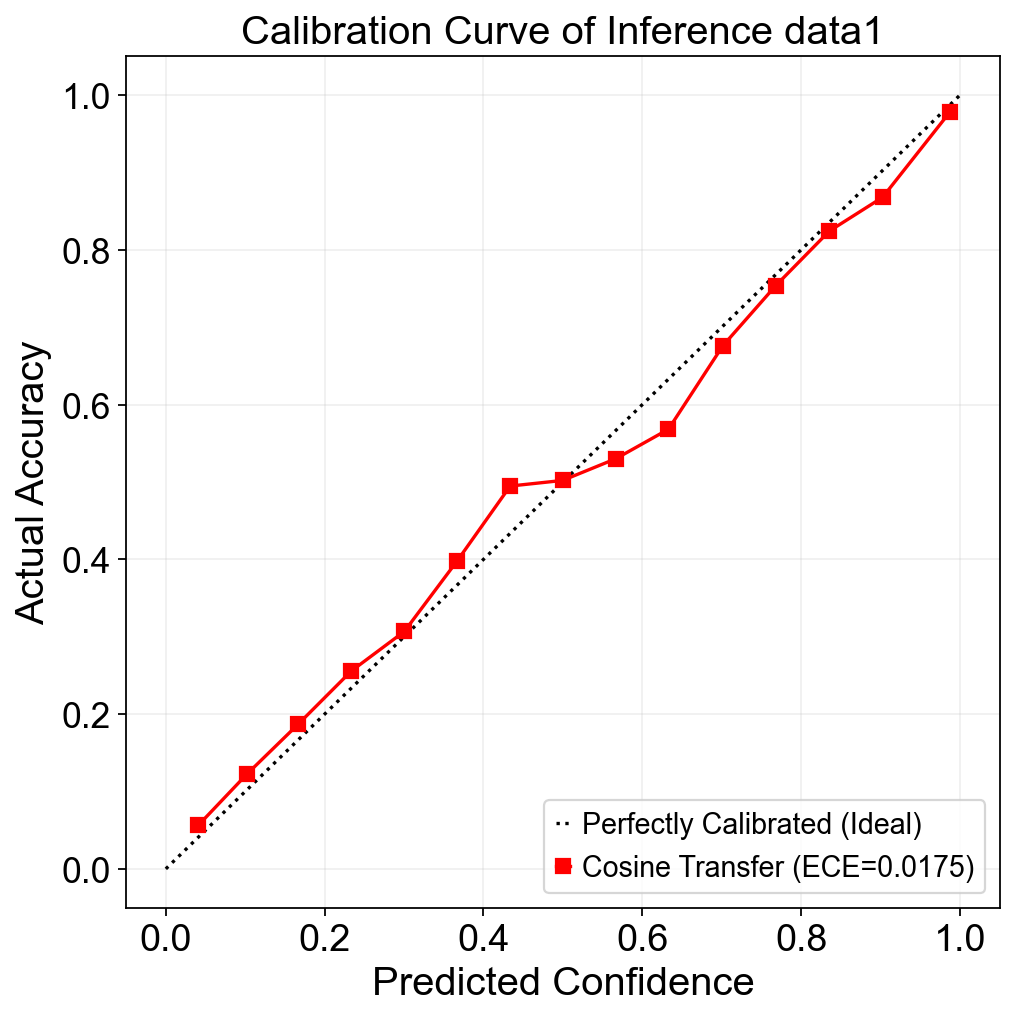

In [106]:
plt.rcParams['font.size'] = 100
ece = evaluate_calibration(adata1,true_label='major_brain_region',pred_label='Transfer_label',conf_key='Confidence')

### Label transfer on inference data2 using cosine similarity

In [58]:
adata2=transfer_labels_by_cosine(pre_adata=Pre_train_adata, new_adata=adata2, label_key="major_brain_region", embedding_key="SpaLP")

In [59]:
adata2

AnnData object with n_obs × n_vars = 43968 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'Transfer_label', 'Confidence', 'Uncertainty'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title',

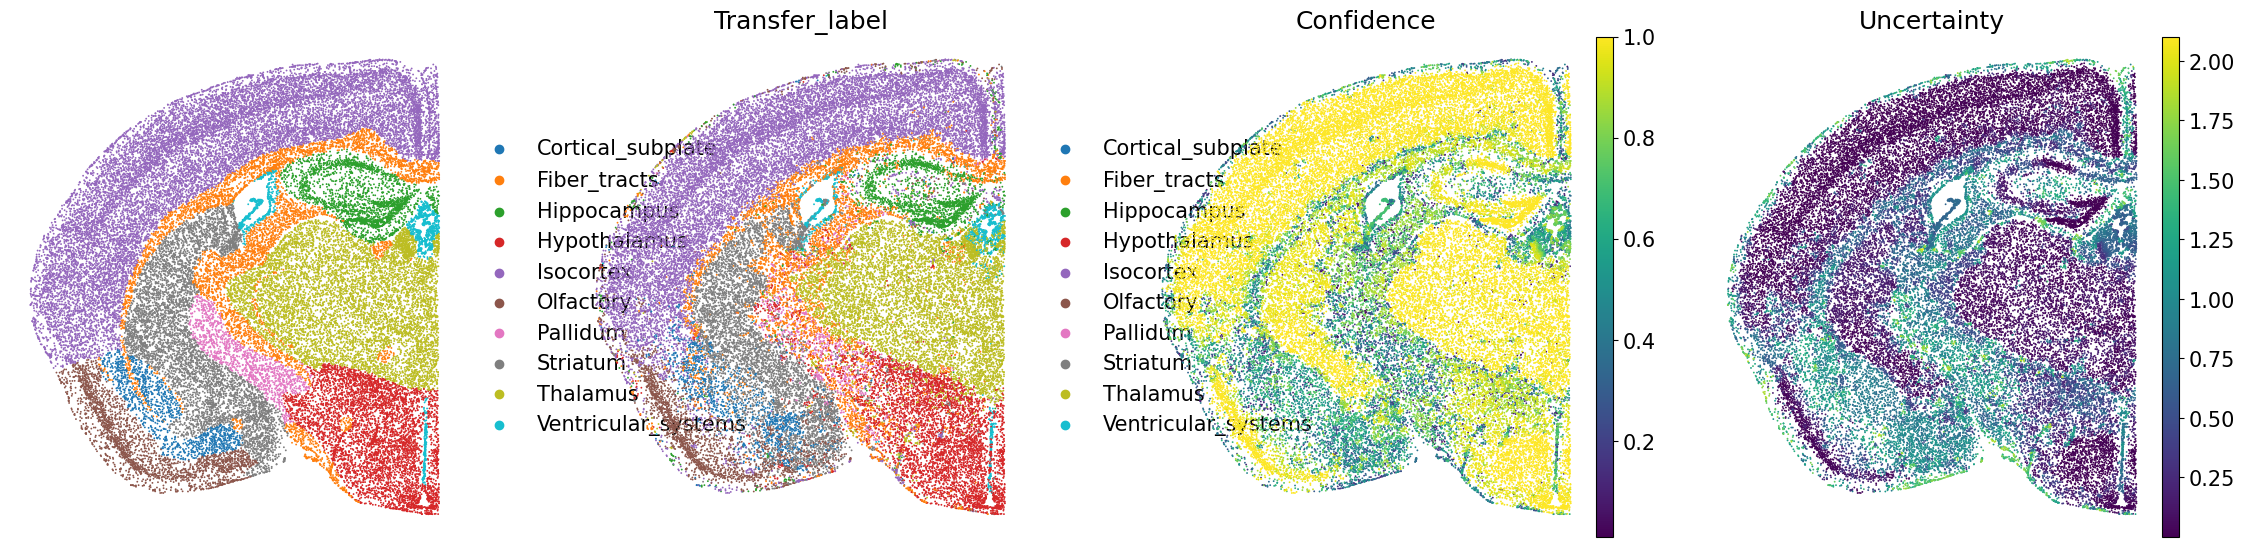

In [64]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata2, basis="spatial",s=7,color=['major_brain_region','Transfer_label','Confidence','Uncertainty'],title='',frameon=False)

### cluster metrics

In [65]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata2.obs['major_brain_region'])
cluster_labels = np.array(adata2.obs['Transfer_label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.7223008289923929
NMI: 0.6140703479398285
AMI: 0.6138912313676854
FMI: 0.7700977746579892
V-Measure: 0.6140703479398286
Homogeneity: 0.6112665150914275


In [103]:
#Calculating calibration curves
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
def evaluate_calibration(new_adata, true_label="True_label", pred_label="Transfer_label", conf_key="Confidence", n_bins=15):
    y_true_str = new_adata.obs[true_label].values
    y_pred_str = new_adata.obs[pred_label].values
    confidences = new_adata.obs[conf_key].values
    confidences = np.clip(confidences, 0.0, 1.0)
    accuracies = (y_true_str == y_pred_str).astype(int)
    
    fraction_of_positives, mean_predicted_value = calibration_curve(accuracies, confidences, n_bins=n_bins, strategy='uniform')
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = (bin_indices == b)
        if np.any(mask):
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.abs(bin_acc - bin_conf) * np.mean(mask)
            
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    plt.figure(figsize=(7, 7))
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (Ideal)")
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", color="red", label=f"Cosine Transfer (ECE={ece:.4f})")
    
    plt.xlabel("Predicted Confidence",fontsize=18)
    plt.ylabel("Actual Accuracy",fontsize=18)
    plt.title("Calibration Curve of Inference data2",fontsize=18)
    plt.legend(loc="lower right")
    plt.tick_params(axis='x', rotation=0, labelsize=17)
    plt.tick_params(axis='y', labelsize=16)
    plt.grid(False, alpha=0.3)
    plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/calibration_curve2.png", dpi=800)
    plt.show()
    
    return ece

Expected Calibration Error (ECE): 0.0131


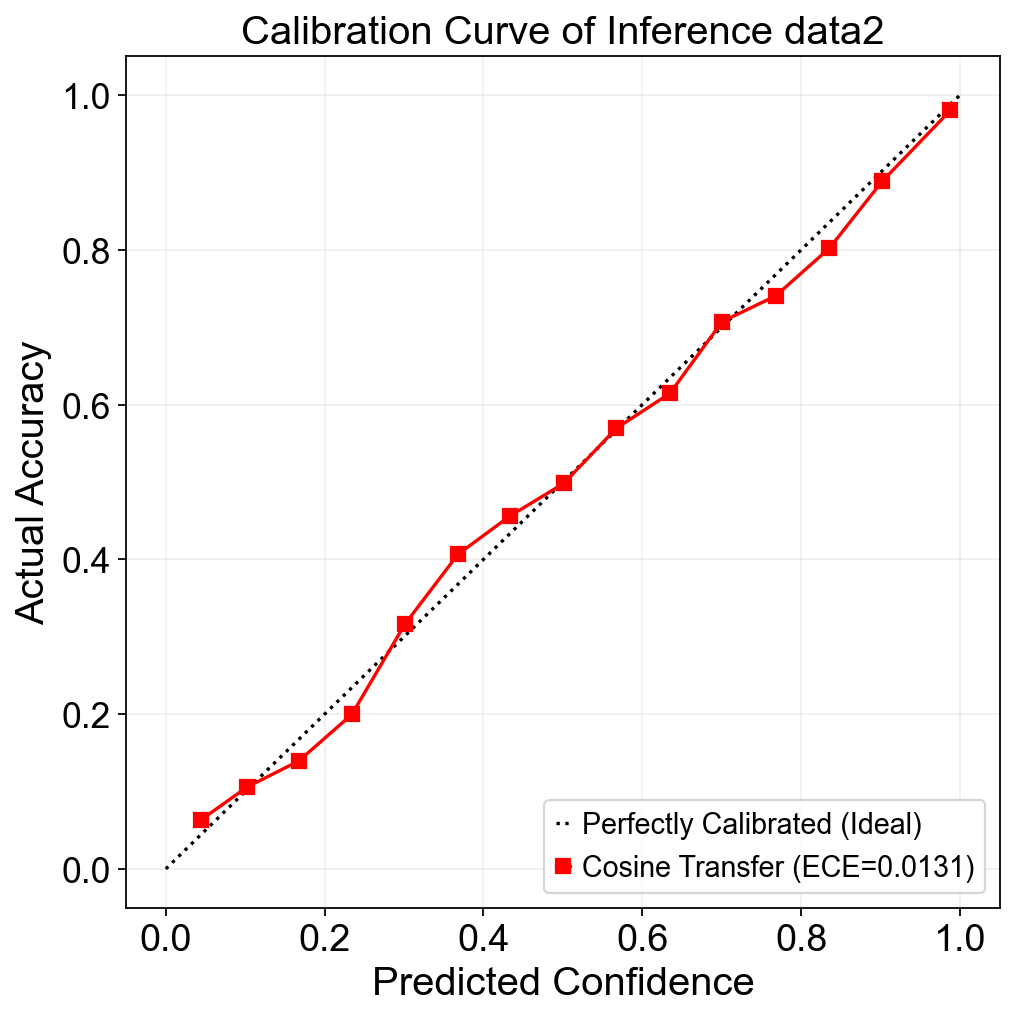

In [104]:
ece = evaluate_calibration(adata2,true_label='major_brain_region',pred_label='Transfer_label',conf_key='Confidence')